In [61]:
import pandas as pd
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

import mediapipe as mp

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

import pickle

from tensorflow.keras import layers, models, callbacks

# DATA PREPARATION

In [64]:
FINAL_DATA_PATH = "../dataset/csv/ds_cctv_v3.csv"
df = pd.read_csv(FINAL_DATA_PATH)
df.head()

,class,x1,y1,z1,v1,x2,y2,z2,v2,x3,...,x149,y149,z149,v149,x150,y150,z150,v150,face_d30,face_s30
0,Celinga Celinguk,0.379137,0.597216,-0.936070,0.997721,0.571154,0.533534,-1.151401,0.995176,0.435377,...,0.192120,1.576425,-1.243571,0.056752,0.192120,1.576425,-1.243571,0.056752,2.0,0.0
1,Celinga Celinguk,0.456846,0.604172,-1.383566,0.997563,0.597769,0.531947,-0.914063,0.995244,0.413901,...,0.160538,1.527582,-0.402668,0.052550,0.160538,1.527582,-0.402668,0.052550,1.0,0.0
2,Celinga Celinguk,0.733066,0.578179,-1.284122,0.997614,0.652434,0.516539,-0.751074,0.995097,0.519533,...,0.183201,1.566506,-1.214096,0.054889,0.183201,1.566506,-1.214096,0.054889,2.0,0.0
3,Celinga Celinguk,0.760213,0.586498,-1.470637,0.996336,0.673799,0.527340,-0.890053,0.992618,0.546215,...,0.166646,1.527519,-0.416431,0.053628,0.166646,1.527519,-0.416431,0.053628,1.0,0.0
4,Celinga Celinguk,0.371994,0.580030,-1.072593,0.996643,0.570744,0.528015,-1.059888,0.993343,0.437132,...,0.164286,1.543727,-1.243575,0.051243,0.164286,1.543727,-1.243575,0.051243,2.0,0.0


## Splitting and Labeling

Splitting the data from csv, and then label each of the output using `LabelEncoder`

In [65]:
X = df.drop(['class'], axis=1)
y = df['class']

Checking the value of each class in the label

In [66]:
y.value_counts()

class
Celinga Celinguk    50
Diam                50
Tutup Muka          50
Name: count, dtype: int64

## Labeling on y

In [67]:
encoder = LabelEncoder()
y_enc = encoder.fit_transform(y)

In [68]:
y_enc[:5], y[:5]

(array([0, 0, 0, 0, 0]),
 0    Celinga Celinguk
 1    Celinga Celinguk
 2    Celinga Celinguk
 3    Celinga Celinguk
 4    Celinga Celinguk
 Name: class, dtype: object)

In [69]:
for i, cls in enumerate(encoder.classes_):
    print(f"{cls} : {i}")

Celinga Celinguk : 0
Diam : 1
Tutup Muka : 2


## Data Splitting

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, train_size=.8, stratify=y_enc)
print(f"""
Total data X_train : {len(X_train)}
Total data X_test : {len(X_test)}
Total data y_train : {len(y_train)}
Total data y_test : {len(y_test)}
""")


Total data X_train : 120
Total data X_test : 30
Total data y_train : 120
Total data y_test : 30



# MODEL PREPARATION & TRAINING (SKLEARN)

In [71]:
all_models = {
    "knn": make_pipeline(StandardScaler(), KNeighborsClassifier()),
    "dtc": make_pipeline(StandardScaler(), DecisionTreeClassifier()),
    "rfc": make_pipeline(StandardScaler(), RandomForestClassifier()),
    "svc": make_pipeline(StandardScaler(), SVC())
}

fitted_models = {}

model_scores = {}

In [72]:
for name, pipeline in all_models.items():
    print(f"Currently, training {name}")
    pipeline.fit(X_train, y_train)
    fitted_models[name] = pipeline
    model_scores[name] = pipeline.score(X_test, y_test)

Currently, training knn
Currently, training dtc
Currently, training rfc
Currently, training svc


In [73]:
for name, score in model_scores.items():
    print(f"{name} : {score}")

knn : 0.8666666666666667
dtc : 0.9666666666666667
rfc : 0.9
svc : 0.9666666666666667


In [74]:
with open("model/best_sklearn_model.pkl", "wb") as f:
    pickle.dump(fitted_models['rfc'], f) # <<<< SAVE BEST MODEL

In [75]:
results = []

for name, model in fitted_models.items():
    y_pred = model.predict(X_test)
    results.append({
        "Model": name.upper(),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1-Score": f1_score(y_test, y_pred, average="weighted")
    })

df_results = pd.DataFrame(results).set_index("Model")
df_results

,Accuracy,Precision,Recall,F1-Score
Model,,,,
KNN,0.866667,0.904762,0.866667,0.868077
DTC,0.966667,0.969697,0.966667,0.966583
RFC,0.900000,0.909091,0.900000,0.899471
SVC,0.966667,0.969697,0.966667,0.966583


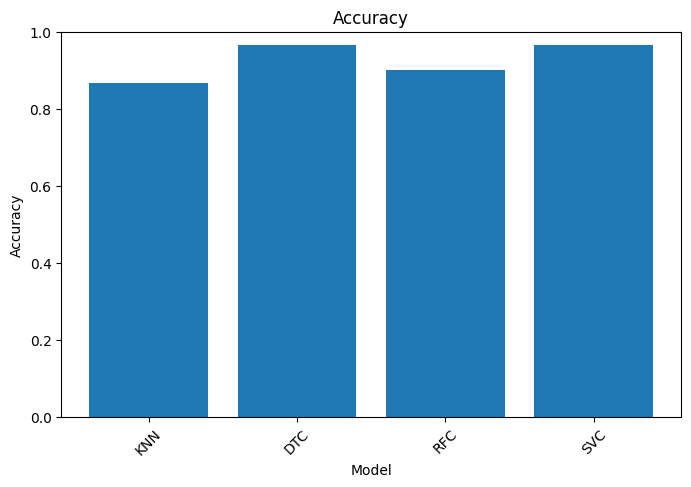

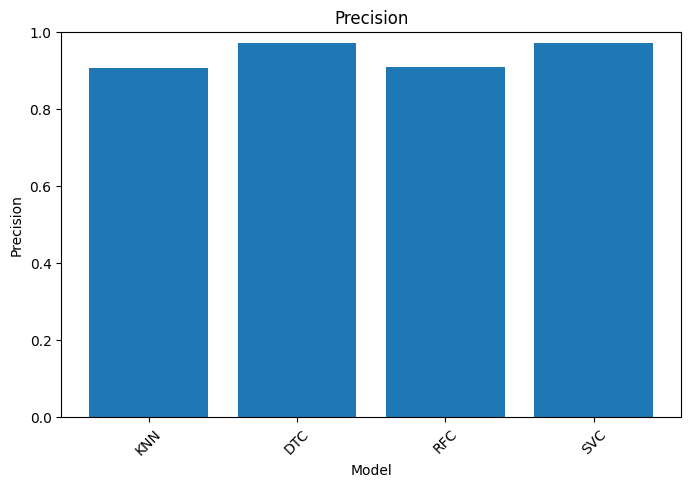

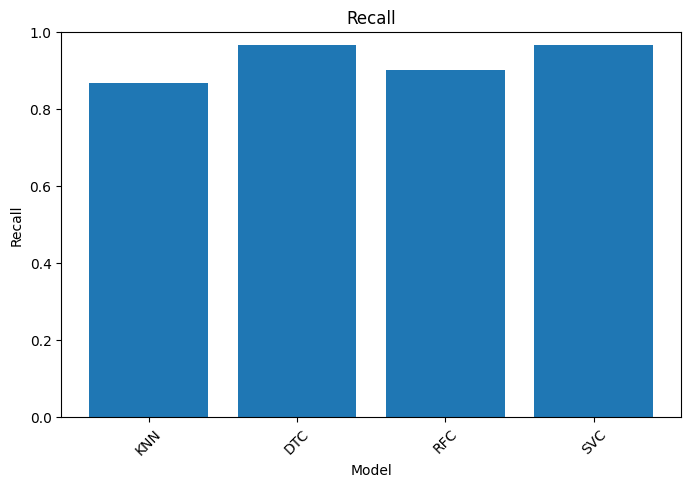

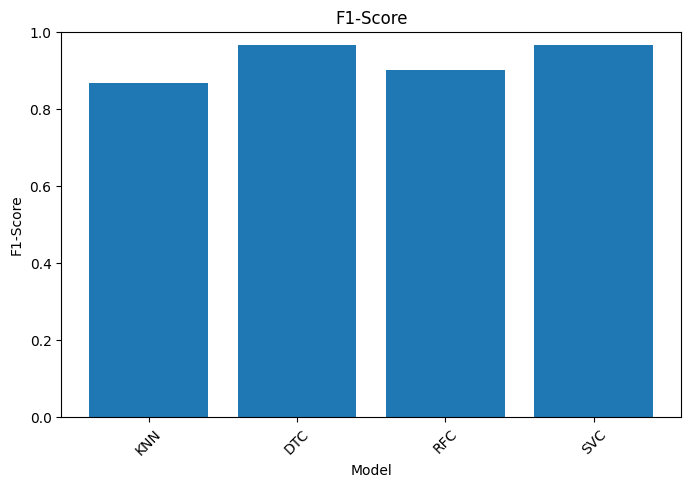

In [86]:
all_metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

for metric in all_metrics:
    plt.figure(figsize=(8, 5))
    plt.bar(df_results.index, df_results[metric])
    plt.title(metric)
    plt.ylabel(metric)
    plt.xlabel("Model")
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    plt.show()

# MODEL PREPARATION & TRAINING (TENSORFLOW)

In [76]:
X_train.shape

(120, 660)

In [77]:
MODEL_INPUT_SHAPE = (X_train.shape[1],)
MODEL_TOTAL_OUTPUT = len(np.unique(y_train))
BEST_MODEL_PATH = "Model/best_nn_model.h5"

In [78]:
print(MODEL_INPUT_SHAPE, MODEL_TOTAL_OUTPUT)

(660,) 3


In [79]:
checkpoint_cb = callbacks.ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",                      
)

earlystop_cb = callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=5,
)

In [80]:
nn_model = models.Sequential([
    layers.Dense(16, input_shape=MODEL_INPUT_SHAPE, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(len(np.unique(y_train)), activation='softmax'),
])

nn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

d:\Project Coding\Research\suspicious_detection_cctv\venv\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [81]:
history = nn_model.fit(
    X_train, y_train, 
    epochs=30,
    validation_split=0.2,
    # callbacks=[checkpoint_cb, earlystop_cb])
    callbacks=[checkpoint_cb])

Epoch 1/30


1/3 ━━━━━━━━━━━━━━━━━━━━ 1s 705ms/step - accuracy: 0.5625 - loss: 1.0649

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.4297 - loss: 1.1284 - val_accuracy: 0.4167 - val_loss: 1.0422
Epoch 2/30
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5312 - loss: 1.0663

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5677 - loss: 1.0271 - val_accuracy: 0.5000 - val_loss: 0.8937
Epoch 3/30
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5938 - loss: 0.8403

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5365 - loss: 0.9077 - val_accuracy: 0.6250 - val_loss: 0.8055
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5755 - loss: 0.8895 - val_accuracy: 0.5417 - val_loss: 0.7764
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5586 - loss: 0.8333 - val_accuracy: 0.6250 - val_loss: 0.7357
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6797 - loss: 0.7706 - val_accuracy: 0.5833 - val_loss: 0.6633
Epoch 7/30
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6562 - loss: 0.6560

...

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7057 - loss: 0.6108 - val_accuracy: 0.7083 - val_loss: 0.4512
Epoch 15/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6641 - loss: 0.5867 - val_accuracy: 0.6667 - val_loss: 0.4533
Epoch 16/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7331 - loss: 0.5108 - val_accuracy: 0.7083 - val_loss: 0.4275
Epoch 17/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8073 - loss: 0.4929 - val_accuracy: 0.7083 - val_loss: 0.4213
Epoch 18/30
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7500 - loss: 0.5370

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7721 - loss: 0.4939 - val_accuracy: 0.7917 - val_loss: 0.4034
Epoch 19/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7956 - loss: 0.4465 - val_accuracy: 0.7500 - val_loss: 0.3915
Epoch 20/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7904 - loss: 0.4583 - val_accuracy: 0.7917 - val_loss: 0.3787
Epoch 21/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8034 - loss: 0.4300 - val_accuracy: 0.7500 - val_loss: 0.3770
Epoch 22/30
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7188 - loss: 0.5270

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7734 - loss: 0.4633 - val_accuracy: 0.8333 - val_loss: 0.3540
Epoch 23/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7865 - loss: 0.3962 - val_accuracy: 0.8333 - val_loss: 0.3455
Epoch 24/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8398 - loss: 0.4050 - val_accuracy: 0.8333 - val_loss: 0.3375
Epoch 25/30
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8438 - loss: 0.3470

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8229 - loss: 0.3741 - val_accuracy: 0.9167 - val_loss: 0.3254
Epoch 26/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9049 - loss: 0.3238 - val_accuracy: 0.8750 - val_loss: 0.3189
Epoch 27/30
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8438 - loss: 0.3106

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8542 - loss: 0.3498 - val_accuracy: 0.9583 - val_loss: 0.2919
Epoch 28/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8320 - loss: 0.3651 - val_accuracy: 0.9167 - val_loss: 0.2841
Epoch 29/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9010 - loss: 0.2901 - val_accuracy: 0.9167 - val_loss: 0.2721
Epoch 30/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8880 - loss: 0.3103 - val_accuracy: 0.9167 - val_loss: 0.2565


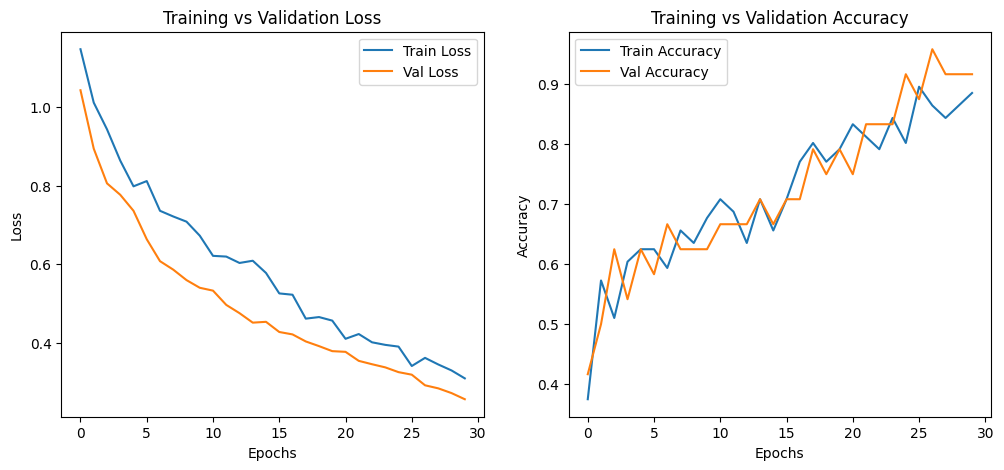

In [82]:
hist = history.history

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist['loss'], label='Train Loss')
plt.plot(hist['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist['accuracy'], label='Train Accuracy')
plt.plot(hist['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.show()